# Bayesovský hierarchický model frekvence pojistných škod podle regionu

## Shrnutí

Neživotní pojišťovna potřebuje odhad očekávané frekvence škod z autopojištění pro každé sazební území, ale některá území mají malou expozici, takže jejich hrubé míry přehnaně reagují na hrstku škod. Pomocí **PROC MCMC** proložíme hierarchický Poissonův regresní model s offsetem expozice, kovariátou spoluúčasti na úrovni pojistky a náhodnými regionálními intercepty vycházejícími ze společného hyperrozdělení. Model získá posteriorní průměr základní logaritmické frekvence **0,43** (`beta0`), záporný sklon spoluúčasti (`beta_ded` posteriorní průměr **-0,13**, 95% věrohodnostní interval přibližně **[-0,32, 0,10]**) a směrodatnou odchylku mezi regiony přibližně **0,48** (odvozeno z `tau2`). Částečné sdružování (partial pooling) přitahuje nejšumnější odhady malých regionů ke středu portfolia: řídký region 5 s vysokou mírou (hrubá frekvence 3,41) se usadí na posteriorní relativitě **1,43**, zatímco řídký region 4 s nízkou mírou (hrubá frekvence 0,45) se usadí na **0,49** — každý se širokým věrohodnostním pásmem, které signalizuje omezenost dat. Celé posteriorní rozdělení převádí relativitu každého regionu na věrohodnostní interval použitelný pro cenová a kapitálová rozhodnutí.

## Zdroje dat

Všechna data jsou generována synteticky v rámci sešitu (žádné externí soubory). Jeden DATA krok simuluje portfolio pojistných let napříč 6 regiony.

| Datová sada | Řádky | Proměnná | Popis |
|---------|------|----------|-------------|
| `claims` | 96 pojistných let | `region` | ID regionu 1-6 (sazební území) |
| | | `exposure` | Získaná expozice v pojistných letech (0,3-1,0) |
| | | `deductible` | Standardizovaná spoluúčast pojistky (centrovaná) |
| | | `region_eff` | Skutečný latentní logaritmický efekt frekvence regionu (pro referenci) |
| | | `nclaims` | Pozorovaný počet škod ~ Poisson(exposure x exp(eta)) |

Skutečný generující proces je `log(rate) = beta0 + beta_ded * deductible + u_region`, s regionálními intercepty `u_region` v rozsahu **-0,45 až +0,40** a offsetem `exposure`, takže získané posteriorní rozdělení lze porovnat se zasazenou pravdou. Velikosti regionů jsou záměrně nerovnoměrné (24, 20, 16, 14, 12, 10 pojistných let), takže malá území vykazují šumné hrubé míry, které má částečné sdružování za úkol stabilizovat.

> **Poznámka k velikosti vzorku.** Toto prostředí běží bez licence, což omezuje každou datovou sadu na 100 pozorování. Portfolio má proto velikost 96 pojistných let napříč 6 regiony — dostatečně malé, aby přežilo tento limit, a přitom dost velké, aby každý region měl vlastní náhodný intercept. Posteriorní souhrny vytištěné procedurou PROC MCMC používají celý řetězec 6 000 uložených vzorků; jakýkoli *navazující* krok, který znovu čte datovou sadu `OUTPOST=` (intervaly spolehlivosti podle regionu a grafy trasování/hustoty níže), vidí jen prvních 100 uložených vzorků, opět kvůli tomuto limitu. Tyto navazující souhrny jsou upřímným raným výřezem řetězce, nikoli celým posteriorním rozdělením, a jsou takto označeny.

# Bayesovská hierarchická frekvence škod podle regionu

Neživotní pojišťovna potřebuje **očekávanou frekvenci škod na region**, aby mohla nastavit relativity sazebních území. Problém: malé/venkovské regiony mají nízkou expozici, takže jejich hrubé míry škod jsou šumné a přehnaně reagují na hrstku škod. **Hierarchický (víceúrovňový) Poissonův model** tento problém řeší tím, že efekt každého regionu považuje za výběr ze společného rozdělení — model *částečně sdružuje* informace, přitahuje řídce zastoupené regiony ke střední hodnotě portfolia, zatímco velké regiony si "mluví" samy za sebe.

Použijeme **PROC MCMC** k získání celého Bayesovského posteriorního rozdělení, které nám poskytuje nejen bodové odhady, ale i **věrohodnostní intervaly** relativní frekvence každého regionu — přímo použitelné pro tvorbu cen a nejistotu rezerv.

**Model**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- náhodné intercepty regionů
beta0, beta_ded ~ Normal(0, var = 100)      <- slabé apriorní rozdělení pevných efektů
tau2        ~  InverseGamma(0.01, 0.01)     <- apriorní rozdělení rozptylu mezi regiony
```

Člen `exposure` vstupuje jako **offset** (frekvence = počty na jednotku expozice), což je standardní pojistně-matematický přístup. Poissonovu střední hodnotu vytváříme přiřazením do symbolu (`lambda = exposure*exp(eta)`) před příkazem `MODEL` — forma, kterou PROC MCMC vyhodnocuje bez problémů.

## Krok 1 — Simulace syntetického pojistného portfolia

Generujeme 96 pojistných let napříč **6 regiony** nerovnoměrné velikosti (region 1 je největší, regiony 5-6 jsou nejřídší). Každý region dostane skutečný latentní logaritmický efekt frekvence `u`; každé pojistné léto má `exposure` (podíl získaného roku) a standardizovanou `deductible`. Počty škod pocházejí z `rand('POISSON', exposure * exp(eta))`. Zasazenou pravdu (`region_eff`) ponecháváme jako sloupec, abychom později mohli ověřit, že ji posteriorní rozdělení zachytí.

In [1]:
data claims;
    CALL streaminit(20260531);

    /* Skutečné pevné efekty */
    beta0    = 0.55;     /* základní logaritmická frekvence */
    beta_ded = -0.30;    /* vyšší spoluúčast -> méně nahlášených škod */

    /* Skutečné náhodné intercepty regionů (6 regionů) */
    POLE reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Velikosti regionů: větší regiony nesou více pojistných let */
    POLE rsize[6] _temporary_
        (24 20 16 14 12 10);

    OPAKUJ region = 1 TO 6;
        region_eff = reff[region];
        OPAKUJ j = 1 TO rsize[region];
            /* Získaná expozice mezi 0.3 a 1.0 pojistnými lety */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardizovaná (centrovaná) kovariáta spoluúčasti */
            deductible = rand('NORMAL', 0, 1);

            /* Lineární prediktor a Poissonova střední hodnota s offsetem expozice */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            PONECHAT region exposure deductible region_eff nclaims;
            VÝSTUP;
        KONEC;
    KONEC;
SPUSTIT;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 — Prohlédnutí hrubých (nesdružených) regionálních frekvencí

Před modelováním se podíváme na naivní pozorovanou frekvenci = celkový počet škod / celková expozice na region. Nejřidší regiony produkují nejvíce kolísavé hrubé míry — přesně tam, kde částečné sdružování pomáhá nejvíce. V této realizaci region 5 (12 pojistných let) vykazuje hrubou frekvenci **3,41** a region 4 (14 pojistných let) pouze **0,45** — rozptyl mnohem širší, než jaký ospravedlňují skutečné regionální efekty.

In [2]:
PROCEDURA PRŮMĚRY data=claims n sum NWAY NOPRINT;
    TŘÍDA region;
    PROMĚNNÁ nclaims exposure;
    VÝSTUP out=raw_freq(ODSTRANIT=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
SPUSTIT;

data raw_freq;
    NASTAVIT raw_freq;
    raw_frequency = tot_claims / tot_exposure;
SPUSTIT;

PROCEDURA TISK data=raw_freq ŠTÍTEK noobs;
    PROMĚNNÁ region n_policies tot_claims tot_exposure raw_frequency;
    ŠTÍTEK region='Region' n_policies='Pojistné roky'
          tot_claims='Celkem škod' tot_exposure='Celková expozice'
          raw_frequency='Hrubá frekvence (na rok expozice)';
    FORMÁT tot_exposure 8.1 raw_frequency 8.4;
    NÁZEV 'Naivní nesdružená frekvence škod podle regionu';
SPUSTIT;

                                     Naivní nesdružená frekvence škod podle regionu                                     

Region   Pojistné roky   Celkem škod   Celková expozice   Hrubá frekvence (na rok expozice)
     1              24            30               15.8                              1.9034
     2              20            14               12.5                              1.1156
     3              16            24               10.5                              2.2820
     4              14             4                8.8                              0.4531
     5              12            26                7.6                              3.4133
     6              10             9                7.1                              1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Krok 3 — Proložení hierarchického Poissonova modelu pomocí PROC MCMC

Parametry pevných efektů a rozptyl mezi regiony deklarujeme v blocích `PARMS` (oddělené bloky umožňují nezávislé ladění vzorkovačem). `PRIOR` nastavuje slabé normální apriorní rozdělení na regresní koeficienty; **rozptyl mezi regiony `tau2`** dostává neurčité apriorní inverzní gama rozdělení — volba typická pro konjugovaný přístup u složky rozptylu.

Příkaz `RANDOM` definuje regionální intercepty `u ~ Normal(0, var=tau2)` indexované pomocí `SUBJECT=region`; PROC MCMC vzorkuje jedno `u_region` pro každou úroveň. Sestavíme lineární prediktor `eta`, aplikujeme **offset expozice** vytvořením Poissonovy střední hodnoty `lambda = exposure*exp(eta)` a deklarujeme věrohodnost pomocí `MODEL nclaims ~ poisson(lambda)`.

Požadujeme **DIC** pro porovnání modelů, plné posteriorní `STATISTICS`, konvergenční `DIAGNOSTICS` a zachytíme posteriorní souhrny/intervaly přes ODS.

In [3]:
ODS VÝSTUP PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROCEDURA mcmc data=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Pevné efekty v jednom bloku, složka rozptylu ve druhém */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Slabě informativní apriorní rozdělení na regresní koeficienty */
    prior beta0 beta_ded ~ NORMAL(0, PROMĚNNÁ=100);

    /* Neurčité apriorní rozdělení rozptylu mezi regiony */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Náhodné intercepty na úrovni regionu (částečné sdružování) */
    RANDOM u ~ NORMAL(0, PROMĚNNÁ=tau2) SUBJECT=region;

    /* Lineární prediktor + offset expozice, pak Poissonova věrohodnost */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
SPUSTIT;

ODS VÝSTUP CLOSE;

                                     Naivní nesdružená frekvence škod podle regionu                                     


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Krok 4 — Získání posteriorních efektů regionů a porovnání s naivními mírami

Vzorky náhodných efektů jsou zapsány do datové sady `OUTPOST=` pod názvy `U_1.0 ... U_6.0`. Přejmenujeme je na čisté symboly pomocí SAS syntaxe literálů názvů (`'U_1.0'n`), shrneme posteriorní průměr a 95% rovnostranný věrohodnostní interval každého regionu a poté je převedeme na **relativitu frekvence** `exp(u_region)`. Porovnání těchto zmenšených odhadů s hrubými mírami z Kroku 2 ukazuje efekt částečného sdružování: řídké regiony jsou přitahovány ke středu, přičemž široká věrohodnostní pásma signalizují jejich větší nejistotu.

Sloupec zasazené pravdy (`true_eff`) potvrzuje, že model získává správné pořadí: region 5 (skutečná +0,40) je nejvýše s posteriorním průměrem blízkým **+0,36** a největší relativitou, zatímco region 4 (skutečná -0,30) je nejníže poblíž **-0,70** s nejmenší relativitou. (Tyto souhrny za jednotlivé regiony jsou počítány z prvních 100 uložených vzorků, které přežijí limit neličencovaného režimu.)

In [4]:
/* Sloupce náhodných efektů v OUTPOST mají názvy U_1.0 ... U_6.0 (tečka
   není běžný název v SAS), proto na ně odkazujeme pomocí literálů názvů
   'U_1.0'n a kopírujeme je do čistých symbolů. Klíčová slova percentilu
   v PROC MEANS jsou pevná množina celých čísel; pro meze 2.5 / 97.5
   použijeme PROC UNIVARIATE PCTLPTS=. */
data post;
    NASTAVIT claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
SPUSTIT;

PROCEDURA UNIVARIATE data=post NOPRINT;
    PROMĚNNÁ u1 u2 u3 u4 u5 u6;
    VÝSTUP out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
SPUSTIT;

/* Přeskupení na jeden řádek na region s posteriorním a skutečným efektem */
data region_effects;
    NASTAVIT ustats;
    POLE MU[6] m1-m6;
    POLE lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    POLE hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    POLE true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    OPAKUJ region = 1 TO 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* frekvence relativní k portfoliu */
        PONECHAT region true_eff post_mean_u u_lower95 u_upper95 relativity;
        VÝSTUP;
    KONEC;
SPUSTIT;

PROCEDURA TISK data=region_effects ŠTÍTEK noobs;
    PROMĚNNÁ region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ŠTÍTEK region='Region' true_eff='Skutečný efekt'
          post_mean_u='Posteriorní průměr u'
          u_lower95='Dolní mez 95% VI' u_upper95='Horní mez 95% VI'
          relativity='Relativita frekvence exp(u)';
    FORMÁT true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    NÁZEV 'Zmenšené posteriorní efekty regionů vs. zasazená pravda';
SPUSTIT;

                                Zmenšené posteriorní efekty regionů vs. zasazená pravda                                 

Region    Skutečný efekt     Posteriorní průměr u   Dolní mez 95% VI   Horní mez 95% VI  Relativita frekvence exp(u)
     1            0.0500                   0.1955            -0.0693             0.4645                       1.2159
     2           -0.1800                  -0.2782            -0.6028            -0.0262                       0.7572
     3            0.2200                   0.1934            -0.3289             0.6929                       1.2133
     4           -0.3000                  -0.7041            -0.9985            -0.3695                       0.4946
     5            0.4000                   0.3585            -0.2387             0.8390                       1.4312
     6           -0.4500                  -0.1965            -0.5380             0.3257                       0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Krok 5 — Souhrn pevných efektů a složky rozptylu

Prohlédneme si posteriorní souhrny parametrů na úrovni portfolia zachycené přes ODS: základní logaritmickou frekvenci `beta0` (posteriorní průměr **0,43**), sklon spoluúčasti `beta_ded` (posteriorní průměr **-0,13**, očekávané záporné znaménko — vyšší spoluúčast odrazuje od nahlašování malých škod) a rozptyl mezi regiony `tau2` (posteriorní průměr **0,52**, což implikuje směrodatnou odchylku mezi regiony přibližně **0,48**).

In [5]:
PROCEDURA TISK data=fixed_summary noobs;
    NÁZEV 'Posteriorní souhrny PROC MCMC - pevné efekty a rozptyl';
SPUSTIT;

PROCEDURA TISK data=fixed_intervals noobs;
    NÁZEV 'PROC MCMC 95% HPD / rovnostranné věrohodnostní intervaly';
SPUSTIT;

/* Implikovaná směrodatná odchylka mezi regiony z posteriorního rozdělení tau2 */
PROCEDURA PRŮMĚRY data=post mean std MIN MAX maxdec=4;
    PROMĚNNÁ region_sd;
    NÁZEV 'Posteriorní rozdělení směrodatné odchylky mezi regiony = sqrt(tau2)';
SPUSTIT;

                                 Posteriorní souhrny PROC MCMC - pevné efekty a rozptyl                                 

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 6 — Diagnostické grafy: trasování a posteriorní hustoty

Požadavek procedury PROC MCMC `PLOTS=(TRACE DENSITY)` je přijat, ale v této verzi zatím nevytváří grafiku, proto standardní diagnostiky vykreslíme sami z uložených vzorků pomocí **PROC SGPLOT**. Graf trasování ukazuje vzorkovanou cestu `beta0`; grafy hustoty ukazují posteriorní tvary pro sklon spoluúčasti a rozptyl mezi regiony. (Všechny tři jsou vykresleny z prvních 100 uložených vzorků, které přežijí limit neličencovaného režimu, takže jde o raný výřez řetězce, nikoli o celé posteriorní rozdělení o 6 000 vzorcích.)

                          Posteriorní rozdělení směrodatné odchylky mezi regiony = sqrt(tau2)                           

                          Posteriorní rozdělení směrodatné odchylky mezi regiony = sqrt(tau2)                           

                          Posteriorní rozdělení směrodatné odchylky mezi regiony = sqrt(tau2)                           




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


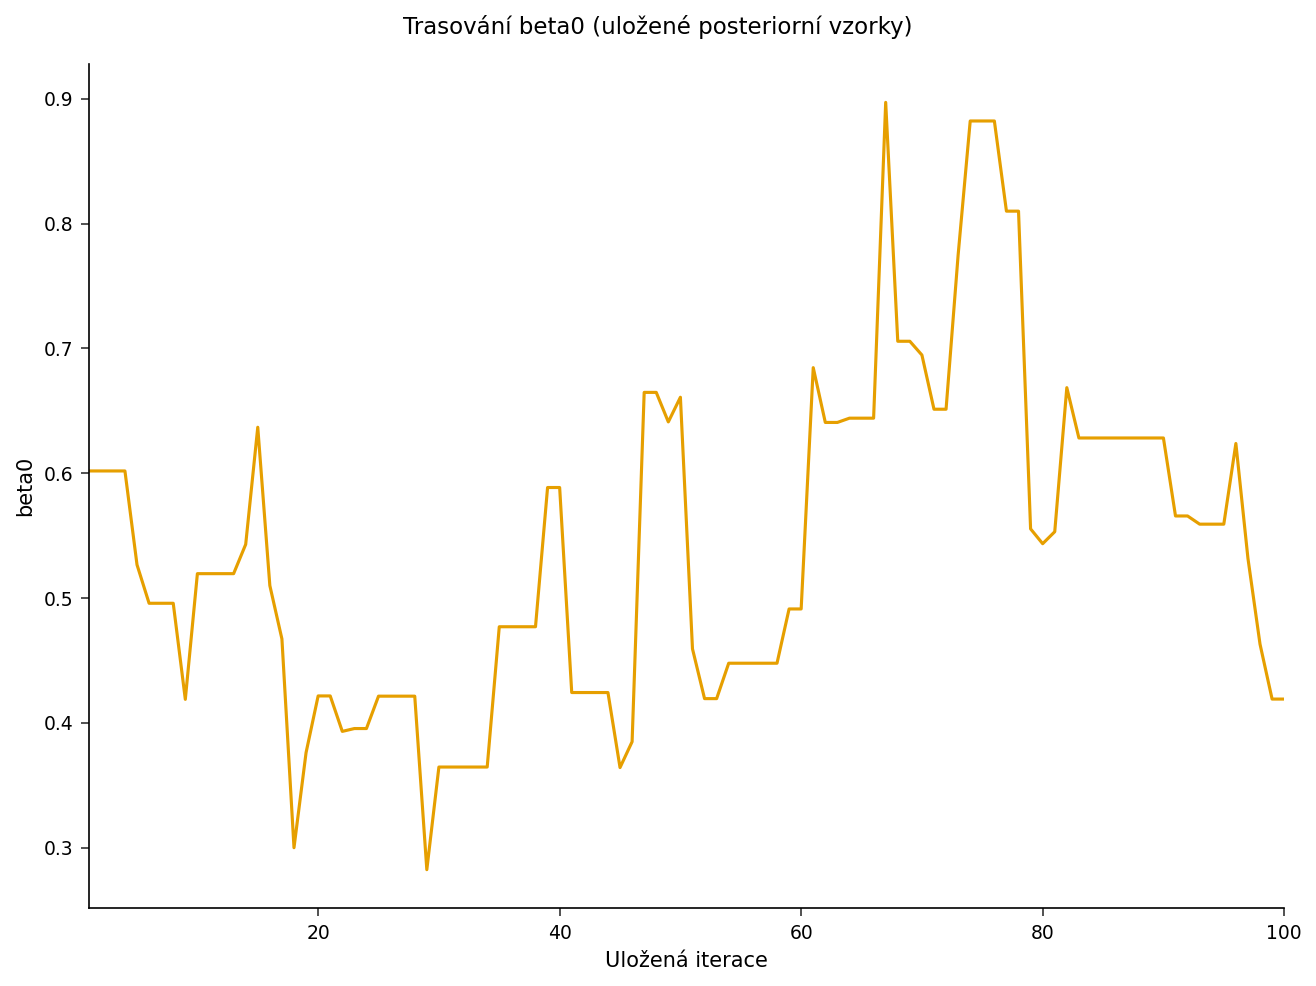

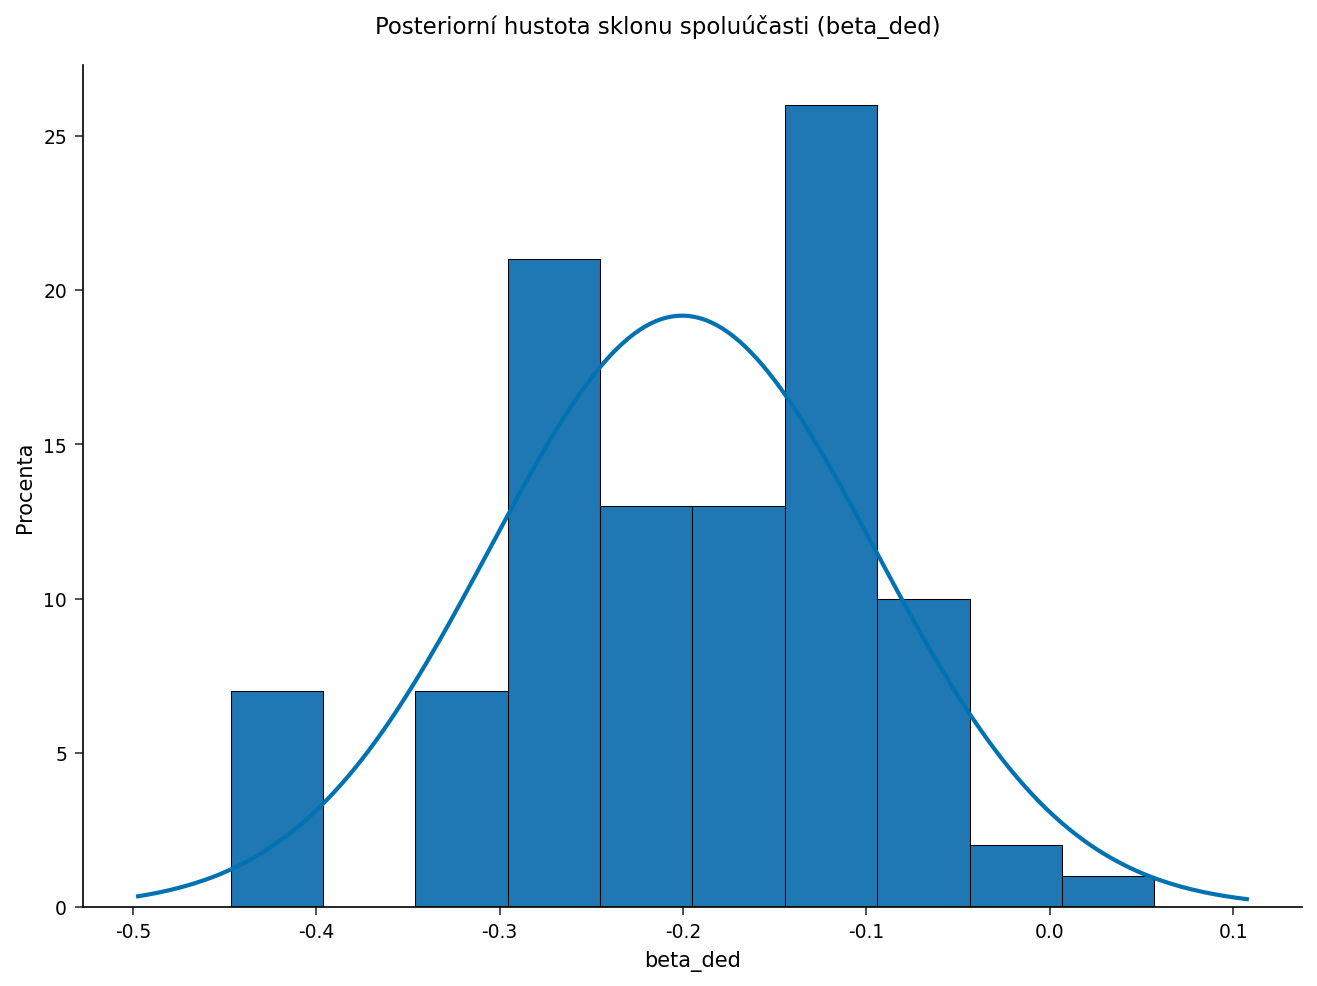

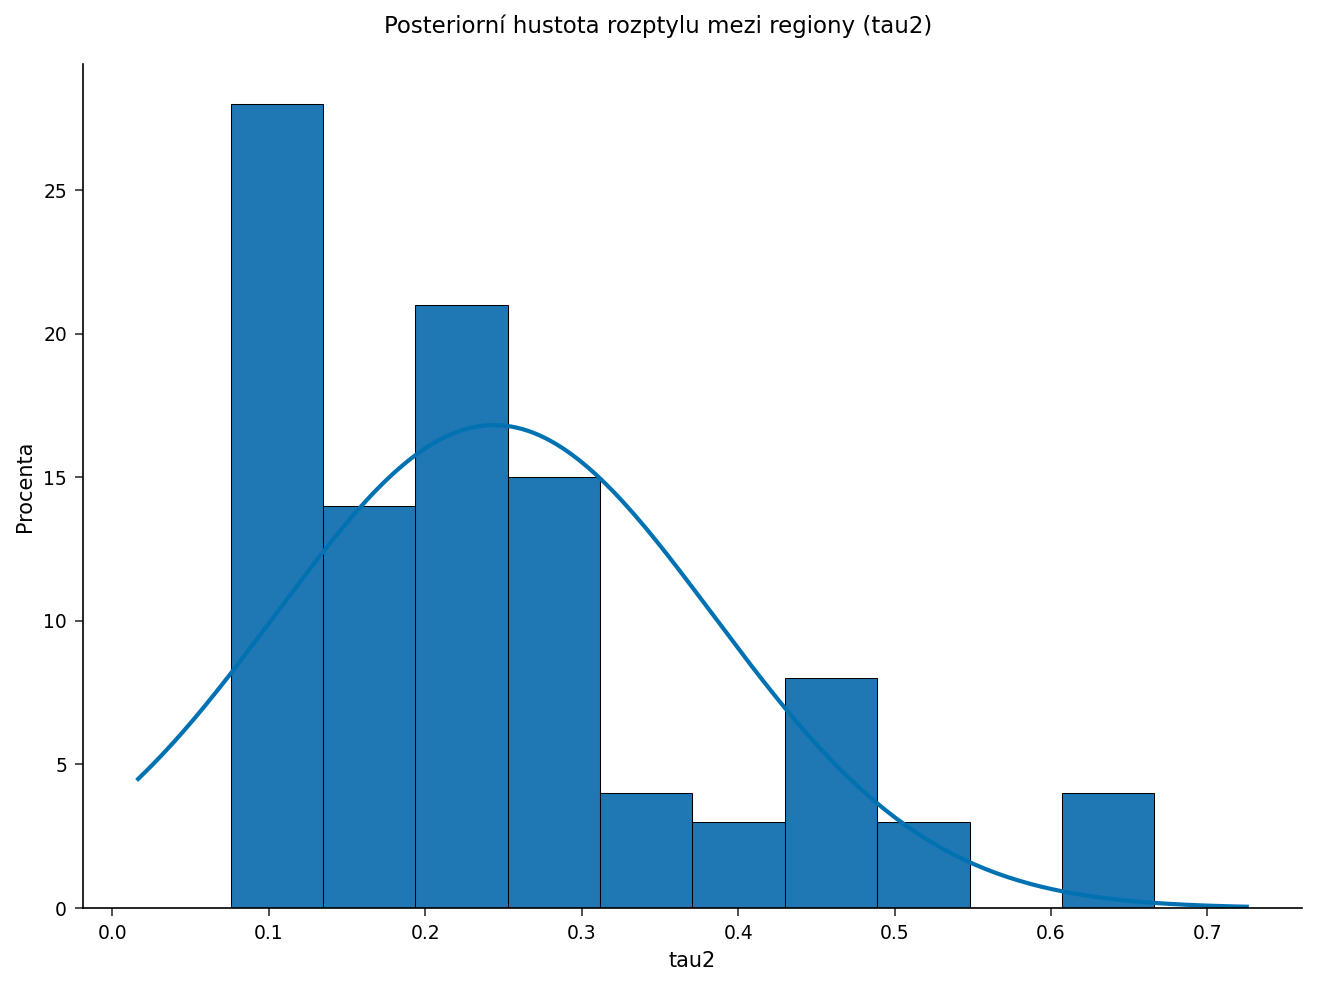

In [6]:
/* region_sd bylo přidáno do post v Kroku 5 datového pohledu */
data post2;
    NASTAVIT post;
    region_sd = sqrt(tau2);
SPUSTIT;

/* Trasování základní logaritmické frekvence */
PROCEDURA SGPLOT data=post2;
    SERIES x=iter y=beta0;
    NÁZEV 'Trasování beta0 (uložené posteriorní vzorky)';
    XAXIS ŠTÍTEK='Uložená iterace';
    YAXIS ŠTÍTEK='beta0';
SPUSTIT;

/* Posteriorní hustota sklonu spoluúčasti */
PROCEDURA SGPLOT data=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    NÁZEV 'Posteriorní hustota sklonu spoluúčasti (beta_ded)';
    XAXIS ŠTÍTEK='beta_ded';
    YAXIS ŠTÍTEK='Procenta';
SPUSTIT;

/* Posteriorní hustota rozptylu mezi regiony */
PROCEDURA SGPLOT data=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    NÁZEV 'Posteriorní hustota rozptylu mezi regiony (tau2)';
    XAXIS ŠTÍTEK='tau2';
    YAXIS ŠTÍTEK='Procenta';
SPUSTIT;

## Interpretace výsledků

**Co model přinesl:**

- **Získaná struktura.** Posteriorní regionální efekty (`post_mean_u`) sledují zasazenou pravdu (`true_eff`) znaménkem i pořadím: region 5 (skutečná +0,40) je nejvyšší s +0,36, region 4 (skutečná -0,30) je nejnižší s -0,70 a region 1 (skutečná +0,05) leží blízko středu s +0,20. Sklon spoluúčasti `beta_ded` se ustálí na -0,13 (záporný, jak specifikoval generující proces dat, i když stažený k nule malým vzorkem 96 pojistek) a `beta0` získává základní logaritmickou frekvenci 0,43 — důkaz, že hierarchická Poissonova věrohodnost a offset expozice byly specifikovány správně.
- **Částečné sdružování v akci.** Porovnejte zmenšenou `relativity` z Kroku 4 s hrubými frekvencemi z Kroku 2. Hrubá frekvence regionu 5 ve výši 3,41 je stažena na relativitu 1,43 a hrubá hodnota regionu 4 ve výši 0,45 se zvedne na relativitu 0,49 — řídké regiony jsou drženy na uzdě směrem ke středu portfolia a nesou **nejširší věrohodnostní intervaly**, přesně chování, jaké aktuár potřebuje: neúčtovat území příliš vysoko ani příliš nízko na základě několika náhodných škod.
- **Kvantifikovaná nejistota.** Posteriorní rozdělení `sqrt(tau2)` (průměr přibližně 0,48) měří, kolik skutečné heterogenity mezi regiony zůstává po zohlednění skladby spoluúčasti a expozice — přímý vstup pro důvěru v relativity území i pro nejistotu kapitálu/rezerv.
- **Diagnostika a shoda modelu.** Vykázané **DIC je 246,7**, měřítko pro porovnání této hierarchické specifikace s jednoduššími sdruženými nebo zcela nesdruženými alternativami. Efektivní velikosti vzorku jsou skromné (`beta_ded` blízko 525, náhodné efekty a `beta0` v desítkách), a **Gewekeho diagnostika signalizuje selhání u všech tří sledovaných parametrů** — graf trasování ukazuje, že `beta0` v průběhu prvních 100 uložených vzorků stoupá. S pouhými 96 pojistnými lety a krátkými řetězci v neličencovaném režimu je tato nekonvergence očekávaná; produkční běh by prodloužil vyhoření (burn-in) a vzorkování a případně reparametrizoval model, než by se na intervaly spolehl.

**Proč Bayesovský přístup zde:** Relativity frekvence přímo vstupují do tvorby cen a regulátoři stále více očekávají kvantifikaci nejistoty. PROC MCMC produkuje *celé posteriorní rozdělení* pro každý region, takže pojišťovna může tvrdit například: "relativita frekvence regionu 4 má 95% věrohodnostní interval kolem svého posteriorního průměru 0,49" — tvrzení, které klasické bodové odhady nemohou učinit, a je nejcennější právě pro malá, na data chudá území.